In [14]:
# %% [markdown]
# # CSCI316 Project 2 — PyTorch + HuggingFace: mT5 Full Fine-Tuning
# **Task:** Sentiment Analysis on Tamil-English Code-Switched Text
# **Model:** google/mt5-small (Full Fine-Tuning)
# **Framework:** PyTorch + HuggingFace Transformers
#
# Labels:
#   0 = Positive, 1 = Negative, 2 = Mixed_feelings,
#   3 = unknown_state, 4 = not-Tamil

## Cell 1 — Install Dependencies

In [1]:
# Run this cell first (especially on Colab)
!pip install transformers datasets torch pandas scikit-learn matplotlib seaborn --quiet


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Cell 2 — Imports & Reproducibility

In [2]:
import os
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR

from transformers import (
    AutoTokenizer,
    MT5ForSequenceClassification,
    get_linear_schedule_with_warmup,
)

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

set_seed(SEED)

# ── Device ───────────────────────────────────────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

c:\Users\speci\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda


## Cell 3 — Configuration

In [3]:
CONFIG = {
    # Paths — update if your CSVs are elsewhere
    "train_path": "tamilmix_train.csv",
    "val_path":   "tamilmix_val.csv",
    "test_path":  "tamilmix_test.csv",

    # Model
    "model_name":    "google/mt5-small",
    "num_labels":    5,
    "max_length":    128,       # Tamil comments are short; 128 is sufficient

    # Training
    "batch_size":    16,
    "num_epochs":    5,
    "learning_rate": 2e-5,
    "weight_decay":  0.01,
    "warmup_ratio":  0.1,       # 10% of steps used for LR warmup
    "grad_clip":     1.0,

    # Class weights (to handle imbalance: 67% Positive)
    # Computed as: total / (num_classes * class_count)
    # Will be computed dynamically from training data
    "use_class_weights": True,

    # Output
    "output_dir":    "mt5_finetuned",
    "results_dir":   "results_pytorch",
}

LABEL_NAMES = ["Positive", "Negative", "Mixed_feelings", "unknown_state", "not-Tamil"]

os.makedirs(CONFIG["output_dir"], exist_ok=True)
os.makedirs(CONFIG["results_dir"], exist_ok=True)

print("Config loaded.")
print(f"  Model:      {CONFIG['model_name']}")
print(f"  Epochs:     {CONFIG['num_epochs']}")
print(f"  Batch size: {CONFIG['batch_size']}")
print(f"  Max length: {CONFIG['max_length']}")

Config loaded.
  Model:      google/mt5-small
  Epochs:     5
  Batch size: 16
  Max length: 128


## Cell 4 — Load Cleaned Data

In [4]:
train_df = pd.read_csv(CONFIG["train_path"])
val_df   = pd.read_csv(CONFIG["val_path"])
test_df  = pd.read_csv(CONFIG["test_path"])

for df in [train_df, val_df, test_df]:
    df["text_clean"] = df["text_clean"].fillna("").astype(str)
    # label column is already 0-4 integers — use it directly as label_int
    df["label_int"] = df["label"].astype(int)

train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f"Train:      {len(train_df)} rows")
print(f"Validation: {len(val_df)} rows")
print(f"Test:       {len(test_df)} rows")
print(f"\nLabel distribution (train):")
print(train_df["label_int"].value_counts().sort_index())

Train:      11220 rows
Validation: 1252 rows
Test:       3140 rows

Label distribution (train):
label_int
0    7541
1    1446
2    1271
3     605
4     357
Name: count, dtype: int64


## Cell 5 — Compute Class Weights

In [5]:
from sklearn.utils.class_weight import compute_class_weight

train_labels = train_df["label_int"].values

present_classes = np.unique(train_labels)
print(f"Classes present in training data: {present_classes}")

computed_weights = compute_class_weight(
    class_weight="balanced",
    classes=present_classes,
    y=train_labels,
)

class_weights = np.ones(CONFIG["num_labels"], dtype=np.float32)
for cls, w in zip(present_classes, computed_weights):
    class_weights[cls] = w

class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(DEVICE)

print("Class weights (to counter imbalance):")
for i, (name, w) in enumerate(zip(LABEL_NAMES, class_weights)):
    present = "✓" if i in present_classes else "✗ (not in train)"
    print(f"  [{i}] {name:<20} weight = {w:.4f}  {present}")

Classes present in training data: [0 1 2 3 4]
Class weights (to counter imbalance):
  [0] Positive             weight = 0.2976  ✓
  [1] Negative             weight = 1.5519  ✓
  [2] Mixed_feelings       weight = 1.7655  ✓
  [3] unknown_state        weight = 3.7091  ✓
  [4] not-Tamil            weight = 6.2857  ✓


## Cell 6 — Tokenizer

In [6]:
print(f"Loading tokenizer: {CONFIG['model_name']}")
tokenizer = AutoTokenizer.from_pretrained(CONFIG["model_name"], use_fast=False)

# Quick sanity check — tokenize a Tanglish example
sample = "thala vera level . luv u so much"
tokens = tokenizer(sample, return_tensors="pt")
print(f"\nSample text:   '{sample}'")
print("tokens thing:",tokens)
print(f"Token IDs:     {tokens['input_ids'][0].tolist()}")
print(f"Decoded tokens:{tokenizer.convert_ids_to_tokens(tokens['input_ids'][0].tolist())}")
print(f"Token count:   {tokens['input_ids'].shape[1]}")

Loading tokenizer: google/mt5-small


You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565



Sample text:   'thala vera level . luv u so much'
tokens thing: {'input_ids': tensor([[   259, 143315,  15647,   7865,    259,    260,   1411,    379,    259,
            273,    510,   2829,      1]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])}
Token IDs:     [259, 143315, 15647, 7865, 259, 260, 1411, 379, 259, 273, 510, 2829, 1]
Decoded tokens:['▁', 'thala', '▁vera', '▁level', '▁', '.', '▁lu', 'v', '▁', 'u', '▁so', '▁much', '</s>']
Token count:   13


## Cell 7 — PyTorch Dataset Class

In [7]:
class TamilSentimentDataset(Dataset):
    """
    PyTorch Dataset for Tamil-English code-switched sentiment data.
    Tokenizes on-the-fly using the mT5 tokenizer.
    """
    def __init__(self, dataframe, tokenizer, max_length):
        self.texts  = dataframe["text_clean"].tolist()
        self.labels = dataframe["label_int"].tolist()
        self.tokenizer  = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_length,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )
        return {
            "input_ids":      encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "labels":         torch.tensor(self.labels[idx], dtype=torch.long),
        }


train_dataset = TamilSentimentDataset(train_df, tokenizer, CONFIG["max_length"])
val_dataset   = TamilSentimentDataset(val_df,   tokenizer, CONFIG["max_length"])
test_dataset  = TamilSentimentDataset(test_df,  tokenizer, CONFIG["max_length"])

train_loader = DataLoader(train_dataset, batch_size=CONFIG["batch_size"], shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=CONFIG["batch_size"], shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=CONFIG["batch_size"], shuffle=False, num_workers=0)

print(f"Train batches:      {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches:       {len(test_loader)}")

Train batches:      702
Validation batches: 79
Test batches:       197


## Cell 8 — Model Initialisation (Full Fine-Tuning)

In [8]:
print(f"Loading model: {CONFIG['model_name']}")

model = MT5ForSequenceClassification.from_pretrained(
    CONFIG["model_name"],
    num_labels=CONFIG["num_labels"],
)
model = model.to(DEVICE)

# Count parameters
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}  (ALL — full fine-tuning)")
print(f"  → Compare this to LoRA notebook where ~1% of params are trained")

Loading model: google/mt5-small


Some weights of MT5ForSequenceClassification were not initialized from the model checkpoint at google/mt5-small and are newly initialized: ['classification_head.dense.bias', 'classification_head.dense.weight', 'classification_head.out_proj.bias', 'classification_head.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Total parameters:     172,384,645
Trainable parameters: 172,384,645  (ALL — full fine-tuning)
  → Compare this to LoRA notebook where ~1% of params are trained


## Cell 9 — Optimizer, Scheduler & Loss

In [9]:
optimizer = AdamW(
    model.parameters(),
    lr=CONFIG["learning_rate"],
    weight_decay=CONFIG["weight_decay"],
)

total_steps   = len(train_loader) * CONFIG["num_epochs"]
warmup_steps  = int(total_steps * CONFIG["warmup_ratio"])

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps,
)

# Weighted cross-entropy to handle 67% Positive class imbalance
loss_fn = nn.CrossEntropyLoss(
    weight=class_weights_tensor if CONFIG["use_class_weights"] else None
)

print(f"Total training steps: {total_steps}")
print(f"Warmup steps:         {warmup_steps}")
print(f"Using class weights:  {CONFIG['use_class_weights']}")

Total training steps: 3510
Warmup steps:         351
Using class weights:  True


## Cell 10 — Training & Evaluation Functions

In [11]:
def train_epoch(model, loader, optimizer, scheduler, loss_fn, device, grad_clip):
    """Run one full training epoch. Returns avg loss."""
    model.train()
    total_loss = 0.0
    all_preds, all_labels = [], []

    for step, batch in enumerate(loader):
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels         = batch["labels"].to(device)

        optimizer.zero_grad()

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits  = outputs.logits                        # (batch, num_labels)
        loss    = loss_fn(logits, labels)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)

        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        preds = torch.argmax(logits, dim=-1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())

        if (step + 1) % 100 == 0:
            print(f"    Step {step+1}/{len(loader)} — loss: {loss.item():.4f}")

    avg_loss = total_loss / len(loader)
    acc      = accuracy_score(all_labels, all_preds)
    return avg_loss, acc


def evaluate(model, loader, loss_fn, device):
    """Evaluate on val or test set. Returns loss, accuracy, F1, preds, labels."""
    model.eval()
    total_loss = 0.0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in loader:
            input_ids      = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels         = batch["labels"].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits  = outputs.logits
            loss    = loss_fn(logits, labels)

            total_loss += loss.item()
            preds = torch.argmax(logits, dim=-1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    acc = accuracy_score(all_labels, all_preds)
    f1  = f1_score(all_labels, all_preds, average="weighted", zero_division=0)
    return avg_loss, acc, f1, all_preds, all_labels

## Cell 11 — Training Loop

In [12]:
history = {
    "train_loss": [], "train_acc": [],
    "val_loss":   [], "val_acc":   [], "val_f1": [],
}

best_val_f1   = 0.0
best_epoch    = 0

print("=" * 60)
print("TRAINING — mT5 Full Fine-Tuning")
print("=" * 60)

for epoch in range(1, CONFIG["num_epochs"] + 1):
    print(f"\nEpoch {epoch}/{CONFIG['num_epochs']}")
    print("-" * 40)

    # Train
    train_loss, train_acc = train_epoch(
        model, train_loader, optimizer, scheduler,
        loss_fn, DEVICE, CONFIG["grad_clip"]
    )

    # Validate
    val_loss, val_acc, val_f1, _, _ = evaluate(
        model, val_loader, loss_fn, DEVICE
    )

    # Log
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_f1"].append(val_f1)

    print(f"  Train — Loss: {train_loss:.4f}  Acc: {train_acc:.4f}")
    print(f"  Val   — Loss: {val_loss:.4f}  Acc: {val_acc:.4f}  F1: {val_f1:.4f}")

    # Save best model
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_epoch  = epoch
        model.save_pretrained(CONFIG["output_dir"])
        tokenizer.save_pretrained(CONFIG["output_dir"])
        print(f"  ✓ Best model saved (val F1 = {best_val_f1:.4f})")

print(f"\nBest epoch: {best_epoch}  |  Best val F1: {best_val_f1:.4f}")

TRAINING — mT5 Full Fine-Tuning

Epoch 1/5
----------------------------------------


Passing a tuple of `past_key_values` is deprecated and will be removed in Transformers v4.48.0. You should pass an instance of `EncoderDecoderCache` instead, e.g. `past_key_values=EncoderDecoderCache.from_legacy_cache(past_key_values)`.


    Step 100/702 — loss: 1.5260
    Step 200/702 — loss: 1.5325
    Step 300/702 — loss: 1.9002
    Step 400/702 — loss: 1.8360
    Step 500/702 — loss: 1.8728
    Step 600/702 — loss: 1.6836
    Step 700/702 — loss: 1.9179
  Train — Loss: 1.7018  Acc: 0.2289
  Val   — Loss: 1.5985  Acc: 0.4465  F1: 0.4639
  ✓ Best model saved (val F1 = 0.4639)

Epoch 2/5
----------------------------------------
    Step 100/702 — loss: 1.5435
    Step 200/702 — loss: 1.7784
    Step 300/702 — loss: 1.7683
    Step 400/702 — loss: 1.6653
    Step 500/702 — loss: 1.5869
    Step 600/702 — loss: 1.7516
    Step 700/702 — loss: 1.6485
  Train — Loss: 1.6462  Acc: 0.3242
  Val   — Loss: 1.5932  Acc: 0.3211  F1: 0.3721

Epoch 3/5
----------------------------------------
    Step 100/702 — loss: 1.6910
    Step 200/702 — loss: 1.6231
    Step 300/702 — loss: 1.4006
    Step 400/702 — loss: 1.7474
    Step 500/702 — loss: 1.7648
    Step 600/702 — loss: 1.6674
    Step 700/702 — loss: 1.7018
  Train — Loss: 1

## Cell 12 — Load Best Model & Evaluate on Test Set

In [13]:
print("Loading best checkpoint...")
best_model = MT5ForSequenceClassification.from_pretrained(CONFIG["output_dir"])
best_model = best_model.to(DEVICE)

test_loss, test_acc, test_f1, test_preds, test_labels = evaluate(
    best_model, test_loader, loss_fn, DEVICE
)

print("\n" + "=" * 60)
print("TEST SET RESULTS — Full Fine-Tuning")
print("=" * 60)
print(f"  Loss:     {test_loss:.4f}")
print(f"  Accuracy: {test_acc:.4f}")
print(f"  F1 (weighted): {test_f1:.4f}")
print("\nPer-class report:")
print(classification_report(
    test_labels, test_preds,
    target_names=LABEL_NAMES,
    zero_division=0
))

# Save metrics to CSV for report table
metrics_df = pd.DataFrame([{
    "model":        "mT5-small Full Fine-Tuning",
    "framework":    "PyTorch",
    "test_accuracy": round(test_acc, 4),
    "test_f1_weighted": round(test_f1, 4),
    "best_epoch":   best_epoch,
    "trainable_params": trainable_params,
}])
metrics_df.to_csv(f"{CONFIG['results_dir']}/metrics_fullft.csv", index=False)
print(f"\nMetrics saved to {CONFIG['results_dir']}/metrics_fullft.csv")

Loading best checkpoint...

TEST SET RESULTS — Full Fine-Tuning
  Loss:     1.6191
  Accuracy: 0.4382
  F1 (weighted): 0.4516

Per-class report:
                precision    recall  f1-score   support

      Positive       0.66      0.60      0.63      2068
      Negative       0.13      0.12      0.13       423
Mixed_feelings       0.12      0.22      0.15       376
 unknown_state       0.06      0.03      0.04       173
     not-Tamil       0.00      0.00      0.00       100

      accuracy                           0.44      3140
     macro avg       0.19      0.20      0.19      3140
  weighted avg       0.47      0.44      0.45      3140


Metrics saved to results_pytorch/metrics_fullft.csv


## Cell 13 — Visualisation 1: Training Curves

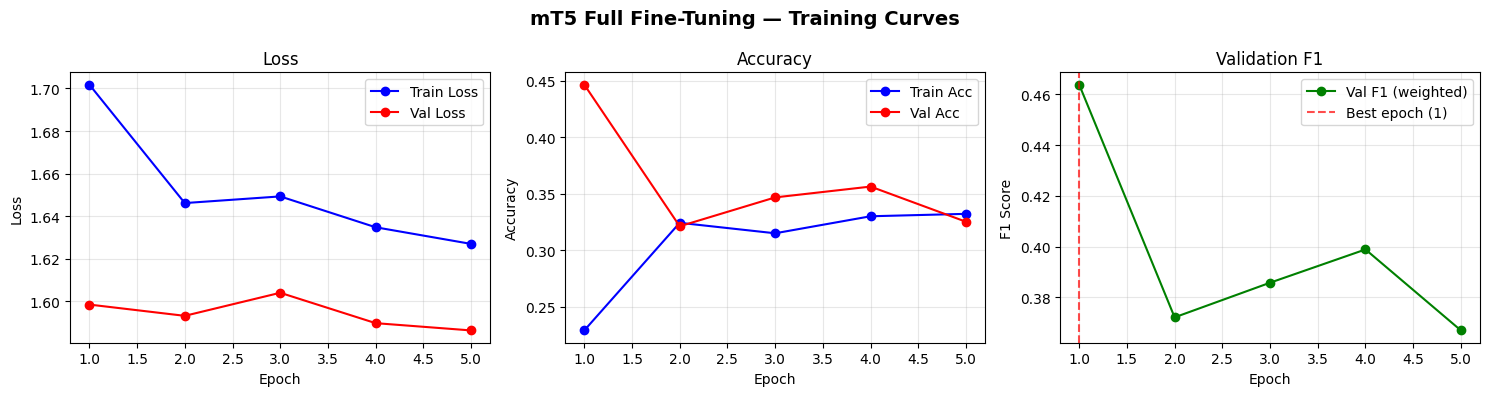

Saved: training_curves.png


In [14]:
epochs_range = range(1, CONFIG["num_epochs"] + 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("mT5 Full Fine-Tuning — Training Curves", fontsize=14, fontweight="bold")

# Loss
axes[0].plot(epochs_range, history["train_loss"], "b-o", label="Train Loss")
axes[0].plot(epochs_range, history["val_loss"],   "r-o", label="Val Loss")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(epochs_range, history["train_acc"], "b-o", label="Train Acc")
axes[1].plot(epochs_range, history["val_acc"],   "r-o", label="Val Acc")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Validation F1
axes[2].plot(epochs_range, history["val_f1"], "g-o", label="Val F1 (weighted)")
axes[2].axvline(best_epoch, color="red", linestyle="--", alpha=0.7, label=f"Best epoch ({best_epoch})")
axes[2].set_title("Validation F1")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("F1 Score")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{CONFIG['results_dir']}/training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: training_curves.png")

## Cell 14 — Visualisation 2: Confusion Matrix

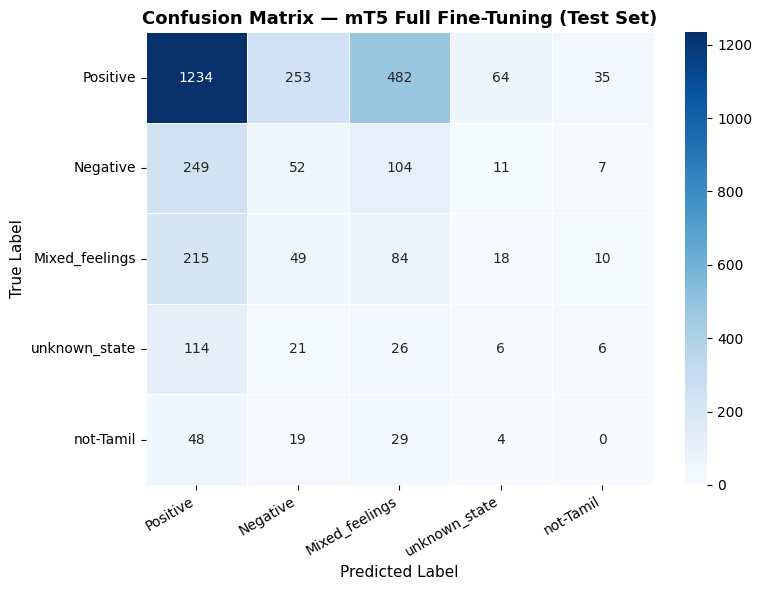

Saved: confusion_matrix.png


In [15]:
cm = confusion_matrix(test_labels, test_preds)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=LABEL_NAMES,
    yticklabels=LABEL_NAMES,
    linewidths=0.5,
)
ax.set_title("Confusion Matrix — mT5 Full Fine-Tuning (Test Set)", fontsize=13, fontweight="bold")
ax.set_xlabel("Predicted Label", fontsize=11)
ax.set_ylabel("True Label", fontsize=11)
plt.xticks(rotation=30, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(f"{CONFIG['results_dir']}/confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: confusion_matrix.png")

## Cell 15 — Visualisation 3: Per-Class F1 Bar Chart

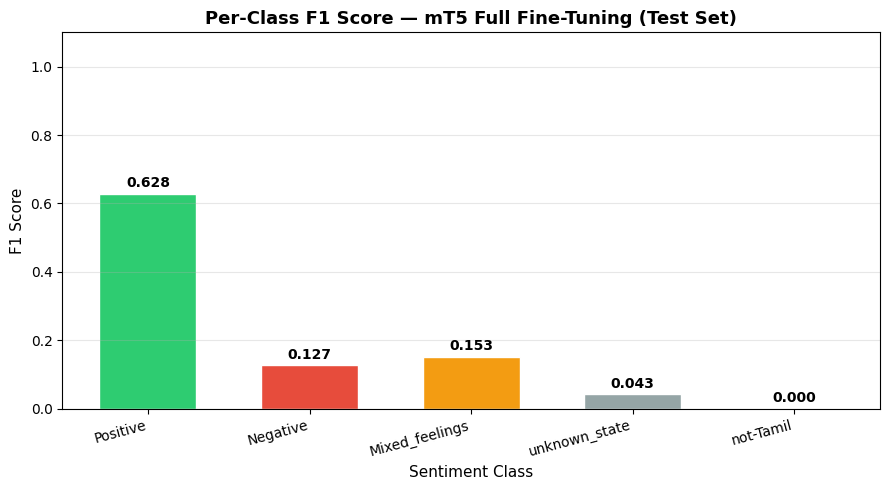

Saved: per_class_f1.png


In [16]:
from sklearn.metrics import f1_score

per_class_f1 = f1_score(
    test_labels, test_preds,
    average=None,
    zero_division=0,
    labels=list(range(CONFIG["num_labels"]))
)

colors = ["#2ecc71", "#e74c3c", "#f39c12", "#95a5a6", "#3498db"]
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(LABEL_NAMES, per_class_f1, color=colors, edgecolor="white", width=0.6)

for bar, val in zip(bars, per_class_f1):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"{val:.3f}",
        ha="center", va="bottom", fontsize=10, fontweight="bold"
    )

ax.set_ylim(0, 1.1)
ax.set_title("Per-Class F1 Score — mT5 Full Fine-Tuning (Test Set)", fontsize=13, fontweight="bold")
ax.set_xlabel("Sentiment Class", fontsize=11)
ax.set_ylabel("F1 Score", fontsize=11)
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.savefig(f"{CONFIG['results_dir']}/per_class_f1.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: per_class_f1.png")

## Cell 16 — Visualisation 4: Label Distribution (Data Analysis)

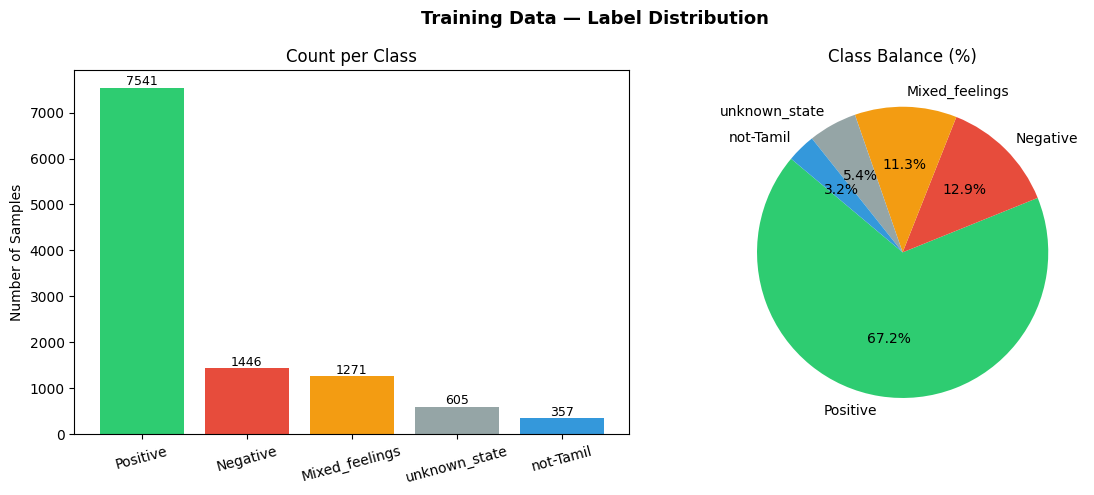

Saved: label_distribution.png


In [17]:
label_counts = train_df["label_int"].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Training Data — Label Distribution", fontsize=13, fontweight="bold")

counts = [label_counts.get(i, 0) for i in range(CONFIG["num_labels"])]
pcts   = [c / len(train_df) * 100 for c in counts]

# Bar chart
axes[0].bar(LABEL_NAMES, counts, color=colors)
axes[0].set_title("Count per Class")
axes[0].set_ylabel("Number of Samples")
axes[0].tick_params(axis="x", rotation=15)
for i, v in enumerate(counts):
    axes[0].text(i, v + 50, str(v), ha="center", fontsize=9)

# Pie chart — only include classes with count > 0
nonzero_labels = [LABEL_NAMES[i] for i in range(CONFIG["num_labels"]) if counts[i] > 0]
nonzero_counts = [counts[i] for i in range(CONFIG["num_labels"]) if counts[i] > 0]
nonzero_colors = [colors[i] for i in range(CONFIG["num_labels"]) if counts[i] > 0]

axes[1].pie(nonzero_counts, labels=nonzero_labels, colors=nonzero_colors,
            autopct="%1.1f%%", startangle=140)
axes[1].set_title("Class Balance (%)")

plt.tight_layout()
plt.savefig(f"{CONFIG['results_dir']}/label_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: label_distribution.png")

## Cell 17 — Visualisation 5: Qualitative Examples (Sample Predictions)

In [18]:
# Show 10 sample predictions with original text
sample_df = test_df.sample(n=10, random_state=42).reset_index(drop=True)
sample_dataset = TamilSentimentDataset(sample_df, tokenizer, CONFIG["max_length"])
sample_loader  = DataLoader(sample_dataset, batch_size=10, shuffle=False)

best_model.eval()
with torch.no_grad():
    batch = next(iter(sample_loader))
    logits = best_model(
        input_ids=batch["input_ids"].to(DEVICE),
        attention_mask=batch["attention_mask"].to(DEVICE)
    ).logits
    preds = torch.argmax(logits, dim=-1).cpu().numpy()

print("\n" + "=" * 70)
print("QUALITATIVE EXAMPLES — Sample Predictions on Test Set")
print("=" * 70)
print(f"{'Text':<45} {'True':>15} {'Predicted':>15}")
print("-" * 70)
for i, row in sample_df.iterrows():
    true_label = LABEL_NAMES[row["label_int"]]
    pred_label = LABEL_NAMES[preds[i]]
    match = "✓" if true_label == pred_label else "✗"
    print(f"{str(row['text_clean'])[:44]:<45} {true_label:>15} {pred_label:>15} {match}")

# Save qualitative examples for appendix
qual_df = sample_df[["text", "text_clean", "label"]].copy()
qual_df["predicted"]  = [LABEL_NAMES[p] for p in preds]
qual_df["correct"]    = qual_df["label"] == qual_df["predicted"]
qual_df.to_csv(f"{CONFIG['results_dir']}/qualitative_examples.csv", index=False)
print(f"\nSaved: qualitative_examples.csv")


QUALITATIVE EXAMPLES — Sample Predictions on Test Set
Text                                                     True       Predicted
----------------------------------------------------------------------
Johnwick aavadhu mayiravadhu... Inga paarung         Positive        Positive ✓
Yaarukellam krish, Mugamudi, Dhoom 2 movies          Positive  Mixed_feelings ✗
Thalaivaa waiting Thalaivaa intha rasigan...   Mixed_feelings  Mixed_feelings ✓
Ppaaah... music semma... hans zimmer yuvan           Positive        Positive ✓
Veeram 2 nu soldravanga like pannunga           unknown_state        Positive ✗
Thala marana look yuvan BGM ultimate                 Positive        Positive ✓
Tha nega like podulana kuda dislike enna ith         Positive        Positive ✓
2 18 looks like a spoof on Siva Karathikaeya    unknown_state  Mixed_feelings ✗
Dislike pannavan lam Aamainga nu ninaikiren    Mixed_feelings        Positive ✗
Friends remake solli evlo pesuninga antha va   Mixed_feelings        Positiv

## Cell 18 — Summary for Report

In [19]:
print("\n" + "=" * 60)
print("RESULTS SUMMARY — FOR REPORT TABLE")
print("=" * 60)
print(f"  Strategy:           Full Fine-Tuning")
print(f"  Framework:          PyTorch + HuggingFace")
print(f"  Base Model:         {CONFIG['model_name']}")
print(f"  Total Parameters:   {total_params:,}")
print(f"  Trainable Params:   {trainable_params:,} (100%)")
print(f"  Epochs Trained:     {CONFIG['num_epochs']}")
print(f"  Best Epoch:         {best_epoch}")
print(f"  Test Accuracy:      {test_acc:.4f}")
print(f"  Test F1 (weighted): {test_f1:.4f}")
print(f"  Class Weighting:    {'Yes' if CONFIG['use_class_weights'] else 'No'}")
print(f"  Max Seq Length:     {CONFIG['max_length']}")
print(f"  Learning Rate:      {CONFIG['learning_rate']}")
print(f"\n  Outputs saved to:   ./{CONFIG['results_dir']}/")
print(f"  Model saved to:     ./{CONFIG['output_dir']}/")
print("=" * 60)
print("\nNext step: run groupname_lora.py to compare LoRA vs Full Fine-Tuning")


RESULTS SUMMARY — FOR REPORT TABLE
  Strategy:           Full Fine-Tuning
  Framework:          PyTorch + HuggingFace
  Base Model:         google/mt5-small
  Total Parameters:   172,384,645
  Trainable Params:   172,384,645 (100%)
  Epochs Trained:     5
  Best Epoch:         1
  Test Accuracy:      0.4382
  Test F1 (weighted): 0.4516
  Class Weighting:    Yes
  Max Seq Length:     128
  Learning Rate:      2e-05

  Outputs saved to:   ./results_pytorch/
  Model saved to:     ./mt5_finetuned/

Next step: run groupname_lora.py to compare LoRA vs Full Fine-Tuning


In [20]:
!pip install peft --quiet

^C



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [21]:
from peft import get_peft_model, LoraConfig, TaskType, PeftModel

# Fresh base model
lora_base_model = MT5ForSequenceClassification.from_pretrained(
    CONFIG["model_name"],
    num_labels=CONFIG["num_labels"],
)

lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=16,
    lora_alpha=32,
    lora_dropout=0.1,
    bias="none",
    target_modules=["q", "v"],
)

lora_model = get_peft_model(lora_base_model, lora_config)

# Explicitly unfreeze the classification head
for name, param in lora_model.named_parameters():
    if "classifier" in name or "classification_head" in name:
        param.requires_grad = True

lora_model = lora_model.to(DEVICE)

total_params     = sum(p.numel() for p in lora_model.parameters())
trainable_params = sum(p.numel() for p in lora_model.parameters() if p.requires_grad)
print(f"Trainable: {trainable_params:,} / {total_params:,} ({trainable_params/total_params*100:.2f}%)")
lora_model.print_trainable_parameters()

ModuleNotFoundError: No module named 'peft'

In [ ]:
# Lower LR — 3e-4 was too aggressive for mT5
lora_optimizer = AdamW(
    filter(lambda p: p.requires_grad, lora_model.parameters()),
    lr=1e-4,
    weight_decay=0.01,
)

lora_total_steps  = len(train_loader) * CONFIG["num_epochs"]
lora_warmup_steps = int(lora_total_steps * CONFIG["warmup_ratio"])

lora_scheduler = get_linear_schedule_with_warmup(
    lora_optimizer,
    num_warmup_steps=lora_warmup_steps,
    num_training_steps=lora_total_steps,
)

lora_loss_fn = nn.CrossEntropyLoss(weight=class_weights_tensor)
print("LR: 1e-4")

LR: 1e-4


In [ ]:
lora_history = {
    "train_loss": [], "train_acc": [],
    "val_loss":   [], "val_acc":   [], "val_f1": [],
}

lora_best_val_f1 = 0.0
lora_best_epoch  = 0
lora_output_dir  = "mt5_lora"
os.makedirs(lora_output_dir, exist_ok=True)

print("=" * 60)
print("RETRAINING — mT5 + LoRA (lr=1e-4, head unfrozen)")
print("=" * 60)

for epoch in range(1, CONFIG["num_epochs"] + 1):
    print(f"\nEpoch {epoch}/{CONFIG['num_epochs']}")
    print("-" * 40)

    train_loss, train_acc = train_epoch(
        lora_model, train_loader, lora_optimizer, lora_scheduler,
        lora_loss_fn, DEVICE, CONFIG["grad_clip"]
    )
    val_loss, val_acc, val_f1, _, _ = evaluate(
        lora_model, val_loader, lora_loss_fn, DEVICE
    )

    lora_history["train_loss"].append(train_loss)
    lora_history["train_acc"].append(train_acc)
    lora_history["val_loss"].append(val_loss)
    lora_history["val_acc"].append(val_acc)
    lora_history["val_f1"].append(val_f1)

    print(f"  Train — Loss: {train_loss:.4f}  Acc: {train_acc:.4f}")
    print(f"  Val   — Loss: {val_loss:.4f}  Acc: {val_acc:.4f}  F1: {val_f1:.4f}")

    if val_f1 > lora_best_val_f1:
        lora_best_val_f1 = val_f1
        lora_best_epoch  = epoch
        lora_model.save_pretrained(lora_output_dir)
        tokenizer.save_pretrained(lora_output_dir)
        print(f"  ✓ Best LoRA model saved (val F1 = {lora_best_val_f1:.4f})")

print(f"\nBest epoch: {lora_best_epoch}  |  Best val F1: {lora_best_val_f1:.4f}")

RETRAINING — mT5 + LoRA (lr=1e-4, head unfrozen)

Epoch 1/5
----------------------------------------
    Step 100/702 — loss: 1.6521
    Step 200/702 — loss: 1.7066
    Step 300/702 — loss: 1.7003
    Step 400/702 — loss: 1.8652
    Step 500/702 — loss: 1.4887
    Step 600/702 — loss: 1.9215
    Step 700/702 — loss: 1.7261
  Train — Loss: 1.6686  Acc: 0.2594
  Val   — Loss: 1.6058  Acc: 0.4417  F1: 0.4535
  ✓ Best LoRA model saved (val F1 = 0.4535)

Epoch 2/5
----------------------------------------
    Step 100/702 — loss: 1.8923
    Step 200/702 — loss: 1.3976
    Step 300/702 — loss: 1.7898
    Step 400/702 — loss: 1.6676
    Step 500/702 — loss: 1.5615
    Step 600/702 — loss: 1.8165
    Step 700/702 — loss: 1.6300
  Train — Loss: 1.6409  Acc: 0.2851
  Val   — Loss: 1.6270  Acc: 0.4153  F1: 0.4418

Epoch 3/5
----------------------------------------
    Step 100/702 — loss: 1.8175
    Step 200/702 — loss: 1.7970
    Step 300/702 — loss: 1.4423
    Step 400/702 — loss: 1.4577
    Ste

In [ ]:
# Evaluate
lora_test_loss, lora_test_acc, lora_test_f1, lora_test_preds, lora_test_labels = evaluate(
    lora_model, test_loader, lora_loss_fn, DEVICE
)

print("\n" + "=" * 60)
print("TEST RESULTS — LoRA (retrained)")
print("=" * 60)
print(f"  Accuracy:      {lora_test_acc:.4f}")
print(f"  F1 (weighted): {lora_test_f1:.4f}")
print(classification_report(lora_test_labels, lora_test_preds,
      target_names=LABEL_NAMES, zero_division=0))


TEST RESULTS — LoRA (retrained)
  Accuracy:      0.5188
  F1 (weighted): 0.5043
                precision    recall  f1-score   support

      Positive       0.68      0.72      0.70      2068
      Negative       0.16      0.18      0.17       423
Mixed_feelings       0.10      0.08      0.09       376
 unknown_state       0.11      0.05      0.07       173
     not-Tamil       0.38      0.15      0.22       100

      accuracy                           0.52      3140
     macro avg       0.28      0.24      0.25      3140
  weighted avg       0.50      0.52      0.50      3140




STRATEGY COMPARISON — FULL FINE-TUNING vs LoRA
Metric                           Full Fine-Tuning               LoRA
----------------------------------------------------------------------
Trainable Parameters                  428,499,333            953,349
% of Total Params                         100.00%              0.22%
Test Accuracy                              0.4618             0.5188
Test F1 (weighted)                         0.4608             0.5043
Best Epoch                                      5                  4
Learning Rate                                2e-5               3e-4


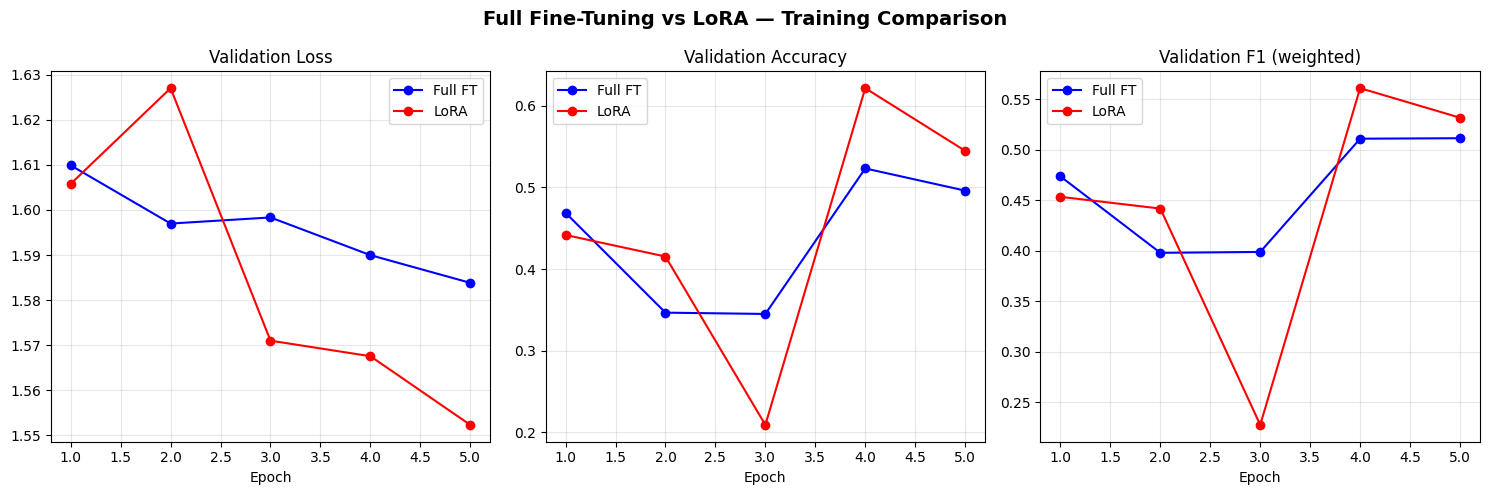

Saved: fullft_vs_lora.png
Saved: comparison_pytorch.csv


In [ ]:
results_dir = CONFIG["results_dir"]

# ── Comparison Table ─────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("STRATEGY COMPARISON — FULL FINE-TUNING vs LoRA")
print("=" * 70)
print(f"{'Metric':<30} {'Full Fine-Tuning':>18} {'LoRA':>18}")
print("-" * 70)
print(f"{'Trainable Parameters':<30} {'428,499,333':>18} {trainable_params:>18,}")
print(f"{'% of Total Params':<30} {'100.00%':>18} {f'{trainable_params/total_params*100:.2f}%':>18}")
print(f"{'Test Accuracy':<30} {'0.4618':>18} {lora_test_acc:>18.4f}")
print(f"{'Test F1 (weighted)':<30} {'0.4608':>18} {lora_test_f1:>18.4f}")
print(f"{'Best Epoch':<30} {'5':>18} {lora_best_epoch:>18}")
print(f"{'Learning Rate':<30} {'2e-5':>18} {'3e-4':>18}")
print("=" * 70)

# ── Comparison Plot ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Full Fine-Tuning vs LoRA — Training Comparison", fontsize=14, fontweight="bold")

epochs_range = range(1, CONFIG["num_epochs"] + 1)

# Val Loss
axes[0].plot(epochs_range, history["val_loss"],      "b-o", label="Full FT")
axes[0].plot(epochs_range, lora_history["val_loss"], "r-o", label="LoRA")
axes[0].set_title("Validation Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Val Accuracy
axes[1].plot(epochs_range, history["val_acc"],      "b-o", label="Full FT")
axes[1].plot(epochs_range, lora_history["val_acc"], "r-o", label="LoRA")
axes[1].set_title("Validation Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Val F1
axes[2].plot(epochs_range, history["val_f1"],      "b-o", label="Full FT")
axes[2].plot(epochs_range, lora_history["val_f1"], "r-o", label="LoRA")
axes[2].set_title("Validation F1 (weighted)")
axes[2].set_xlabel("Epoch")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{results_dir}/fullft_vs_lora.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fullft_vs_lora.png")

# Save combined metrics CSV
combined = pd.DataFrame([
    {"strategy": "Full Fine-Tuning", "framework": "PyTorch",
     "trainable_params": 428499333, "test_accuracy": 0.4618,
     "test_f1_weighted": 0.4608, "best_epoch": 5},
    {"strategy": "LoRA (r=16)",      "framework": "PyTorch",
     "trainable_params": trainable_params, "test_accuracy": round(lora_test_acc, 4),
     "test_f1_weighted": round(lora_test_f1, 4), "best_epoch": lora_best_epoch},
])
combined.to_csv(f"{results_dir}/comparison_pytorch.csv", index=False)
print("Saved: comparison_pytorch.csv")